In [10]:
import os
import random
import numpy as np
import torch
from torch import nn, Tensor
import torch.nn.functional as F
from torch.utils.data import DataLoader
from torchvision import datasets, transforms

# Import common utilities from HTB Evasion Library
from htb_ai_library import (
    set_reproducibility,
    SimpleCNN,
    get_mnist_loaders,
    mnist_denormalize,
    train_model,
    evaluate_accuracy
)

# Configure reproducibility
set_reproducibility(1337)

In [11]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")


In [12]:
from torchvision import datasets, transforms
from torch.utils.data import DataLoader
import os

# =========================
# Function to load dataset
# =========================
def load_test_dataset(data_path, test_bs):
    transform = transforms.Compose([
        transforms.Resize((224, 224)),  # ResNet expects 224x224
        transforms.ToTensor(),
        transforms.Normalize(
            mean=[0.485, 0.456, 0.406], 
            std=[0.229, 0.224, 0.225]
        )
    ])

    test_dir  = os.path.join(data_path, "test")
    test_dataset = datasets.ImageFolder(test_dir, transform=transform)
    test_loader = DataLoader(
        test_dataset, batch_size=test_bs, shuffle=False, num_workers=4
    )
    n_classes = len(test_dataset.classes)
    return test_loader, n_classes


In [13]:
DATA_PATH = "Sorted"  # path to your PFA2/Sorted folder
TEST_BATCH_SIZE = 32

test_loader, n_classes = load_test_dataset(DATA_PATH, TEST_BATCH_SIZE)


In [14]:
def _input_gradient(model: nn.Module, x: Tensor, y: Tensor) -> Tensor:
    """Return gradient of loss with respect to input tensor x.

    Args:
        model: Neural network in evaluation mode
        x: Input images to compute gradients for
        y: True labels for loss computation

    Returns:
        Tensor: Gradient tensor with same shape as x
    """
    x_req = x.clone().detach().requires_grad_(True)
    _, loss = _forward_and_loss(model, x_req, y)
    model.zero_grad(set_to_none=True)
    loss.backward()
    return x_req.grad.detach()

In [15]:
import torch
from torch.utils.data import DataLoader
from torchvision import datasets, transforms
import torch.nn.functional as F
import os

# =========================
# 1) Configuration
# =========================
DATA_PATH = r"C:\Users\lenovo LOQ\PFA2\Sorted"  # dossier contenant test\benign, test\adware...
TEST_BATCH_SIZE = 32
EPSILON = 0.1  # force de l'attaque FGSM
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# =========================
# 2) Transformations du dataset
# =========================
transform = transforms.Compose([
    transforms.Resize((224, 224)),  # ResNet attend 224x224
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

# =========================
# 3) Chargement du dataset de test
# =========================
test_dataset = datasets.ImageFolder(root=os.path.join(DATA_PATH, "test"), transform=transform)
test_loader = DataLoader(test_dataset, batch_size=TEST_BATCH_SIZE, shuffle=False)
num_classes = len(test_dataset.classes)

print(f"Nombre de classes: {num_classes}")
print(f"Classes: {test_dataset.classes}")

# =========================
# 4) Charger le modèle TorchScript
# =========================
model_path = r"C:\Users\lenovo LOQ\PFA2\malware_classifier.pth"
model = torch.jit.load(model_path, map_location=device)
model.eval()
model.to(device)

# =========================
# 5) Définition de l'attaque FGSM
# =========================
def fgsm_attack(model, images, labels, epsilon, targeted=False):
    images = images.clone().detach().to(device)
    labels = labels.to(device)
    images.requires_grad = True

    outputs = model(images)
    loss = F.cross_entropy(outputs, labels)
    model.zero_grad()
    loss.backward()

    grad_sign = images.grad.sign()
    if targeted:
        # pour attaque ciblée, on soustrait le gradient
        adv_images = images - epsilon * grad_sign
    else:
        adv_images = images + epsilon * grad_sign

    adv_images = torch.clamp(adv_images, 0, 1)
    return adv_images.detach()

# =========================
# 6) Évaluer sur la première batch
# =========================
images, labels = next(iter(test_loader))
images, labels = images.to(device), labels.to(device)

# Prédictions sur images propres
with torch.no_grad():
    clean_pred = model(images).argmax(dim=1)

# Génération d'images adversariales
x_adv = fgsm_attack(model, images, labels, EPSILON, targeted=False)

# Prédictions sur images adversariales
with torch.no_grad():
    adv_pred = model(x_adv).argmax(dim=1)

# Calcul du succès de l'attaque
originally_correct = (clean_pred == labels)
flipped = (adv_pred != labels) & originally_correct
success = flipped.sum().item() / max(int(originally_correct.sum().item()), 1)

print(f"FGSM flips (première batch): {success:.2%}")


Nombre de classes: 8
Classes: ['adware', 'backdoor', 'benign', 'downloader', 'spyware', 'trojan', 'virus', 'worm']
FGSM flips (première batch): 100.00%


In [16]:
test_dataset = datasets.ImageFolder(root="C:\\Users\\lenovo LOQ\\PFA2\\Sorted\\test"
, transform=transform)


In [17]:
import os
print(os.getcwd())


C:\Users\lenovo LOQ\PFA2


Classe réelle : adware
Classe prédite avant FGSM : adware
Classe prédite après FGSM : benign


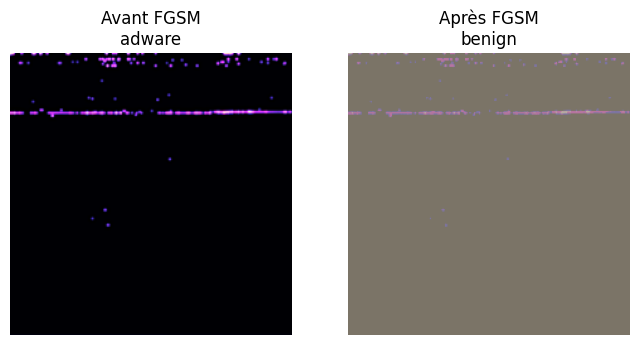

In [18]:
import matplotlib.pyplot as plt
import torch
import torchvision.transforms as T

# =========================
# 1) Choisir une image du batch
# =========================
idx = 0  # indice de l'image dans le batch
image = images[idx:idx+1]  # garde la dimension batch
label = labels[idx:idx+1]

# =========================
# 2) Prédiction sur l'image originale
# =========================
with torch.no_grad():
    pred = model(image).argmax(dim=1)

print(f"Classe réelle : {test_dataset.classes[label.item()]}")
print(f"Classe prédite avant FGSM : {test_dataset.classes[pred.item()]}")

# =========================
# 3) Générer l'image adversariale
# =========================
x_adv_single = fgsm_attack(model, image, label, epsilon=0.1, targeted=False)

with torch.no_grad():
    adv_pred = model(x_adv_single).argmax(dim=1)

print(f"Classe prédite après FGSM : {test_dataset.classes[adv_pred.item()]}")

# =========================
# 4) Fonction pour afficher les images
# =========================
def imshow(tensor_img, title=None):
    # tensor_img : (1, C, H, W) ou (C, H, W)
    if tensor_img.dim() == 4:
        tensor_img = tensor_img.squeeze(0)
    # denormalize
    inv_normalize = T.Normalize(
        mean=[-0.485/0.229, -0.456/0.224, -0.406/0.225],
        std=[1/0.229, 1/0.224, 1/0.225]
    )
    img = inv_normalize(tensor_img).clamp(0,1)  # remettre dans [0,1]
    img = img.permute(1,2,0).cpu().numpy()
    
    plt.imshow(img)
    if title:
        plt.title(title)
    plt.axis('off')

# =========================
# 5) Afficher les images avant et après
# =========================
plt.figure(figsize=(8,4))
plt.subplot(1,2,1)
imshow(image, title=f"Avant FGSM\n{test_dataset.classes[pred.item()]}")
plt.subplot(1,2,2)
imshow(x_adv_single, title=f"Après FGSM\n{test_dataset.classes[adv_pred.item()]}")
plt.show()


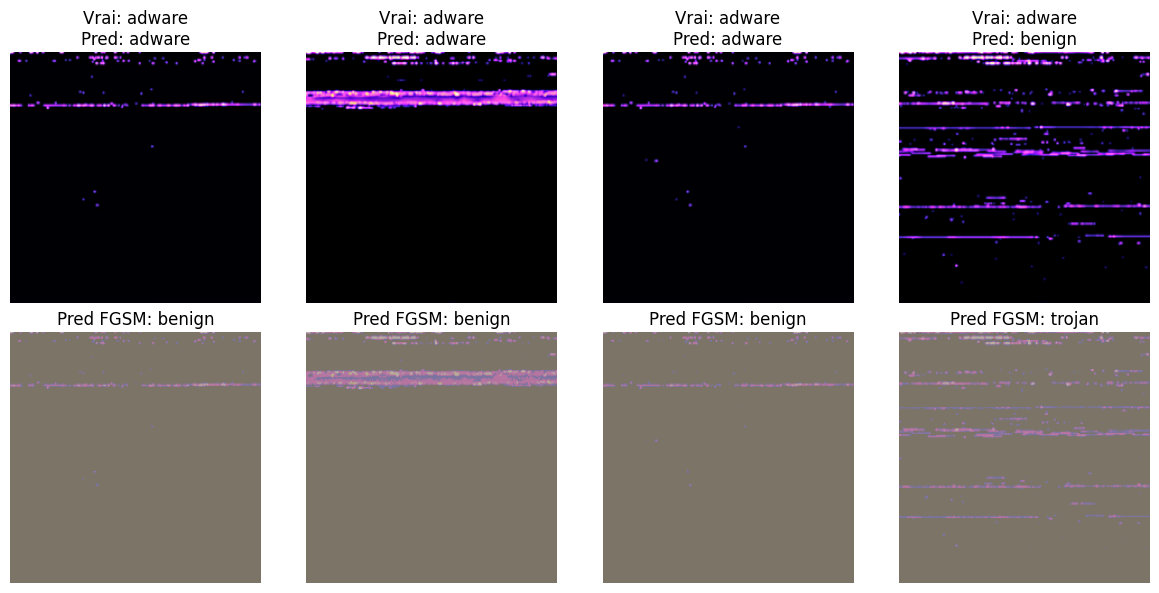

In [20]:
import matplotlib.pyplot as plt
import torch
import torchvision.transforms as T

# =========================
# 1) Paramètres
# =========================
epsilon = 0.5
num_images = 4  # combien d'images afficher
images_batch, labels_batch = next(iter(test_loader))
images_batch, labels_batch = images_batch.to(device), labels_batch.to(device)

# =========================
# 2) Fonction pour afficher une image (denormalisée)
# =========================
def show_image(tensor_img):
    inv_normalize = T.Normalize(
        mean=[-0.485/0.229, -0.456/0.224, -0.406/0.225],
        std=[1/0.229, 1/0.224, 1/0.225]
    )
    img = inv_normalize(tensor_img.squeeze()).clamp(0,1)
    img = img.permute(1,2,0).cpu().numpy()
    plt.imshow(img)
    plt.axis('off')

# =========================
# 3) Générer les adversarials
# =========================
x_adv_batch = fgsm_attack(model, images_batch[:num_images], labels_batch[:num_images], epsilon, targeted=False)

# =========================
# 4) Prédictions
# =========================
with torch.no_grad():
    clean_preds = model(images_batch[:num_images]).argmax(dim=1)
    adv_preds = model(x_adv_batch).argmax(dim=1)

# =========================
# 5) Affichage côte à côte
# =========================
plt.figure(figsize=(12,6))
for i in range(num_images):
    # image originale
    plt.subplot(2, num_images, i+1)
    show_image(images_batch[i])
    plt.title(f"Vrai: {test_dataset.classes[labels_batch[i]]}\nPred: {test_dataset.classes[clean_preds[i]]}")

    # image adversariale
    plt.subplot(2, num_images, i+1+num_images)
    show_image(x_adv_batch[i])
    plt.title(f"Pred FGSM: {test_dataset.classes[adv_preds[i]]}")

plt.tight_layout()
plt.show()
